In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)

from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("LondonCars2014.csv")

### Performing EDA on the dataset

In [3]:
df.head()

,Make,Model,Year,Mileage,Price,Body Style,Ex Color,In Color,Engine,Transmission,Doors
0,Toyota,Avalon XLE,2014,4725,28995,Sedan,Gray,Black,6 Cyl,Automatic,4
1,Ford,Escape SE,2014,17201,24994,SUV,Silver,Black,4 Cyl,Automatic,4
2,Hyundai,Santa Fe Sport,2014,6279,25998,SUV,Silver,Gray,4 Cyl,Automatic,4
3,Ford,Escape SE,2014,16262,26684,SUV,Black,Black,4 Cyl,Automatic,4
4,Jeep,Grand Cherokee Limited Edition,2014,35572,33440,SUV,Black,Black,6 Cyl,Automatic,4


In [4]:
df.tail()

,Make,Model,Year,Mileage,Price,Body Style,Ex Color,In Color,Engine,Transmission,Doors
9075,Chevrolet,Malibu LT,2010,40340,12998,Sedan,Silver,Black,4 Cyl,Automatic,4
9076,Ford,Edge SEL,2009,43169,18495,SUV,Blue,Gray,6 Cyl,Automatic,4
9077,Dodge,Avenger SXT,2012,6761,14944,Sedan,Silver,Black,4 Cyl,Automatic,4
9078,Mercedes-Benz,ML 350,2011,38215,35900,SUV,Silver,Black,6 Cyl,Automatic,4
9079,Nissan,Altima SL,2010,44065,13499,Sedan,Gray,Black,4 Cyl,Automatic,4


In [5]:
print("Nulls:\n", df.isnull().sum())

Nulls:
 Make            0
Model           0
Year            0
Mileage         0
Price           0
Body Style      0
Ex Color        0
In Color        0
Engine          0
Transmission    0
Doors           0
dtype: int64


In [6]:
df.describe(include='all')

,Make,Model,Year,Mileage,Price,Body Style,Ex Color,In Color,Engine,Transmission,Doors
count,9080,9080,9080.000000,9080.000000,9080.000000,9080,9080,9080,9080,9080,9080.000000
unique,49,1060,NaN,NaN,NaN,10,15,9,10,2,NaN
top,Nissan,Altima S,NaN,NaN,NaN,Sedan,Black,Black,6 Cyl,Automatic,NaN
freq,1035,197,NaN,NaN,NaN,3905,2404,4164,4313,8797,NaN
mean,NaN,NaN,2010.498018,41875.531057,24410.926652,NaN,NaN,NaN,NaN,NaN,3.821035
std,NaN,NaN,2.773451,33146.564303,16300.355339,NaN,NaN,NaN,NaN,NaN,0.561866
min,NaN,NaN,1990.000000,1.000000,1490.000000,NaN,NaN,NaN,NaN,NaN,2.000000
25%,NaN,NaN,2010.000000,20112.250000,15987.750000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,2011.000000,33532.000000,21500.000000,NaN,NaN,NaN,NaN,NaN,4.000000
75%,NaN,NaN,2012.000000,52564.500000,28998.000000,NaN,NaN,NaN,NaN,NaN,4.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9080 entries, 0 to 9079
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Make          9080 non-null   object
 1   Model         9080 non-null   object
 2   Year          9080 non-null   int64 
 3   Mileage       9080 non-null   int64 
 4   Price         9080 non-null   int64 
 5   Body Style    9080 non-null   object
 6   Ex Color      9080 non-null   object
 7   In Color      9080 non-null   object
 8   Engine        9080 non-null   object
 9   Transmission  9080 non-null   object
 10  Doors         9080 non-null   int64 
dtypes: int64(4), object(7)
memory usage: 780.4+ KB


In [7]:
df = df.astype({'Make':'category', 'Model':'category', 'Year':'int32', 
                'Mileage':'int32', 'Price':'int64', 'Body Style':'category', 
                'Ex Color':'category' , 'In Color':'category', 
                'Engine':'category', 'Transmission':'category', 'Doors':'int32'})

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9080 entries, 0 to 9079
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Make          9080 non-null   category
 1   Model         9080 non-null   category
 2   Year          9080 non-null   int32   
 3   Mileage       9080 non-null   int32   
 4   Price         9080 non-null   int64   
 5   Body Style    9080 non-null   category
 6   Ex Color      9080 non-null   category
 7   In Color      9080 non-null   category
 8   Engine        9080 non-null   category
 9   Transmission  9080 non-null   category
 10  Doors         9080 non-null   int32   
dtypes: category(7), int32(3), int64(1)
memory usage: 292.3 KB


In [10]:
df.describe(include='all')

,Make,Model,Year,Mileage,Price,Body Style,Ex Color,In Color,Engine,Transmission,Doors
count,9080,9080,9080.000000,9080.000000,9080.000000,9080,9080,9080,9080,9080,9080.000000
unique,49,1060,NaN,NaN,NaN,10,15,9,10,2,NaN
top,Nissan,Altima S,NaN,NaN,NaN,Sedan,Black,Black,6 Cyl,Automatic,NaN
freq,1035,197,NaN,NaN,NaN,3905,2404,4164,4313,8797,NaN
mean,NaN,NaN,2010.498018,41875.531057,24410.926652,NaN,NaN,NaN,NaN,NaN,3.821035
std,NaN,NaN,2.773451,33146.564303,16300.355339,NaN,NaN,NaN,NaN,NaN,0.561866
min,NaN,NaN,1990.000000,1.000000,1490.000000,NaN,NaN,NaN,NaN,NaN,2.000000
25%,NaN,NaN,2010.000000,20112.250000,15987.750000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,2011.000000,33532.000000,21500.000000,NaN,NaN,NaN,NaN,NaN,4.000000
75%,NaN,NaN,2012.000000,52564.500000,28998.000000,NaN,NaN,NaN,NaN,NaN,4.000000


In [11]:
df['Price'].describe()

count      9080.000000
mean      24410.926652
std       16300.355339
min        1490.000000
25%       15987.750000
50%       21500.000000
75%       28998.000000
max      499898.000000
Name: Price, dtype: float64

In [12]:
print('Correlation:')
df[["Price", "Mileage"]].corr(numeric_only=True)

Correlation:


,Price,Mileage
Price,1.000000,-0.405068
Mileage,-0.405068,1.000000


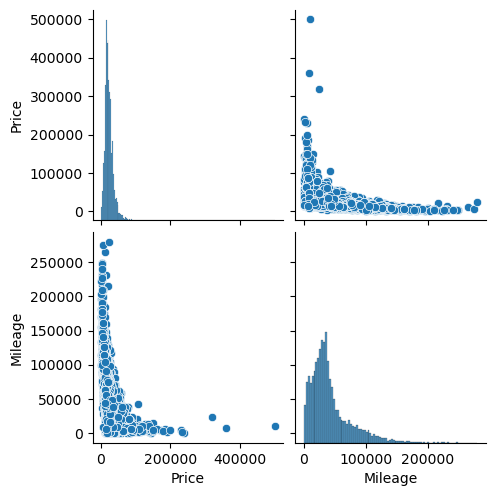

In [13]:
sns.pairplot(df[["Price", "Mileage"]])

### Performing Data Preprocessing

In [8]:
# Fetching categorical columns
cat_cols = df.select_dtypes(include='category').columns.tolist()
print("Categorical columns requiring encoding:\n", cat_cols)

print("\nUnique value counts:")
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique values")

Categorical columns requiring encoding:
 ['Make', 'Model', 'Body Style', 'Ex Color', 'In Color', 'Engine', 'Transmission']

Unique value counts:
  Make: 49 unique values
  Model: 1060 unique values
  Body Style: 10 unique values
  Ex Color: 15 unique values
  In Color: 9 unique values
  Engine: 10 unique values
  Transmission: 2 unique values


In [ ]:
df_encoded = df.copy()

In [17]:
df_encoded

,Make,Model,Year,Mileage,Price,Body Style,Ex Color,In Color,Engine,Transmission,Doors
0,Toyota,Avalon XLE,2014,4725,28995,Sedan,Gray,Black,6 Cyl,Automatic,4
1,Ford,Escape SE,2014,17201,24994,SUV,Silver,Black,4 Cyl,Automatic,4
2,Hyundai,Santa Fe Sport,2014,6279,25998,SUV,Silver,Gray,4 Cyl,Automatic,4
3,Ford,Escape SE,2014,16262,26684,SUV,Black,Black,4 Cyl,Automatic,4
4,Jeep,Grand Cherokee Limited Edition,2014,35572,33440,SUV,Black,Black,6 Cyl,Automatic,4
...,...,...,...,...,...,...,...,...,...,...,...
9075,Chevrolet,Malibu LT,2010,40340,12998,Sedan,Silver,Black,4 Cyl,Automatic,4
9076,Ford,Edge SEL,2009,43169,18495,SUV,Blue,Gray,6 Cyl,Automatic,4
9077,Dodge,Avenger SXT,2012,6761,14944,Sedan,Silver,Black,4 Cyl,Automatic,4
9078,Mercedes-Benz,ML 350,2011,38215,35900,SUV,Silver,Black,6 Cyl,Automatic,4


In [18]:
# ── Label Encoding, ONLY for very high cardinality variables
le = LabelEncoder()
df_encoded['Model'] = le.fit_transform(df_encoded['Model'].astype(str))

In [19]:
# ── One-Hot Encoding, all other categorical columns
ohe_cols = ['Make', 'Body Style', 'Ex Color', 'In Color', 
            'Engine', 'Transmission']
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True, dtype=int)

In [20]:
print(f"Shape after encoding: {df_encoded.shape}")

Shape after encoding: (9080, 94)


In [21]:
df_encoded.head()

,Model,Year,Mileage,Price,Doors,Make_Aston,Make_Audi,Make_BMW,Make_Bentley,Make_Buick,...,Engine_12 Cyl,Engine_3 Cyl,Engine_4 Cyl,Engine_5 Cyl,Engine_6 Cyl,Engine_8 Cyl,Engine_Electric,Engine_Hybrid,Engine_Rotary,Transmission_Manual
0,134,2014,4725,28995,4,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,353,2014,17201,24994,4,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,840,2014,6279,25998,4,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,353,2014,16262,26684,4,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,485,2014,35572,33440,4,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [22]:
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

print(f"Training set : {X_train.shape}")
print(f"Testing set  : {X_test.shape}")

Training set : (6356, 93)
Testing set  : (2724, 93)


In [23]:
#Normaliing numeric fields other than OHE  

numeric_cols = ['Year', 'Mileage', 'Doors', 'Model']
scaler_X = StandardScaler()

X_train[numeric_cols] = scaler_X.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler_X.transform(X_test[numeric_cols])

In [ ]:
scaler_y = StandardScaler()

y_train = scaler_y.fit_transform(y_train.values.reshape(-1,1)).flatten()
y_test  = scaler_y.transform(y_test.values.reshape(-1,1)).flatten()

#### Performing Data Preprocessing for Classification

In [70]:
def bin_price(price):
    if price < 15987:
        return 'low'
    elif price <= 48500:
        return 'medium'
    else:
        return 'high'

In [95]:
df_encoded_clf = df.copy()

In [96]:
df_encoded_clf['Price_label'] = df_encoded_clf['Price'].apply(bin_price)

In [97]:

print("Price class distribution:")
print(df_encoded_clf['Price_label'].value_counts())
print("Percentage:")
print(df_encoded_clf['Price_label'].value_counts(normalize=True).mul(100).round(1))

Price class distribution:
Price_label
medium    6397
low       2268
high       415
Name: count, dtype: int64
Percentage:
Price_label
medium    70.5
low       25.0
high       4.6
Name: proportion, dtype: float64


In [98]:
df_encoded_clf.head()

,Make,Model,Year,Mileage,Price,Body Style,Ex Color,In Color,Engine,Transmission,Doors,Price_label
0,Toyota,Avalon XLE,2014,4725,28995,Sedan,Gray,Black,6 Cyl,Automatic,4,medium
1,Ford,Escape SE,2014,17201,24994,SUV,Silver,Black,4 Cyl,Automatic,4,medium
2,Hyundai,Santa Fe Sport,2014,6279,25998,SUV,Silver,Gray,4 Cyl,Automatic,4,medium
3,Ford,Escape SE,2014,16262,26684,SUV,Black,Black,4 Cyl,Automatic,4,medium
4,Jeep,Grand Cherokee Limited Edition,2014,35572,33440,SUV,Black,Black,6 Cyl,Automatic,4,medium


In [100]:
# Performing Encoding for classification

df_encoded_clf['Model'] = le.fit_transform(df_encoded_clf['Model'].astype(str))

# One-Hot Encoding for all other categoricals
ohe_cols_clf = ['Make', 'Body Style', 'Ex Color', 
            'In Color', 'Engine', 'Transmission']
df_encoded_clf = pd.get_dummies(df_encoded_clf, columns=ohe_cols_clf, drop_first=True, dtype=int)

# encoding target label in three classes
price_order = {'low': 0, 'medium': 1, 'high': 2}
df_encoded_clf['Price_label'] = df_encoded_clf['Price_label'].map(price_order)


print("Shape after encoding:", df_encoded_clf.shape)

Shape after encoding: (9080, 95)


In [102]:
df_encoded_clf.tail()

,Model,Year,Mileage,Price,Doors,Price_label,Make_Aston,Make_Audi,Make_BMW,Make_Bentley,...,Engine_12 Cyl,Engine_3 Cyl,Engine_4 Cyl,Engine_5 Cyl,Engine_6 Cyl,Engine_8 Cyl,Engine_Electric,Engine_Hybrid,Engine_Rotary,Transmission_Manual
9075,607,2010,40340,12998,4,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
9076,324,2009,43169,18495,4,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
9077,138,2012,6761,14944,4,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
9078,600,2011,38215,35900,4,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
9079,117,2010,44065,13499,4,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [103]:
# Define X and y for CLASSIFICATION

make_cols  = [col for col in df_encoded_clf.columns if col.startswith('Make_')]
X_clf      = df_encoded_clf[make_cols + ['Year', 'Mileage']]
y_clf      = df_encoded_clf['Price_label']    

print("Feature matrix:", X_clf.shape)
print("Target classes:", y_clf.unique())

Feature matrix: (9080, 50)
Target classes: [1 0 2]


In [115]:
X_clf.tail()

,Make_Aston,Make_Audi,Make_BMW,Make_Bentley,Make_Buick,Make_Cadillac,Make_Chevrolet,Make_Chrysler,Make_Dodge,Make_Ferrari,...,Make_Scion,Make_Smart,Make_Subaru,Make_Suzuki,Make_Tesla,Make_Toyota,Make_Volkswagen,Make_Volvo,Year,Mileage
9075,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,2010,40340
9076,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2009,43169
9077,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,2012,6761
9078,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2011,38215
9079,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2010,44065


In [111]:
# Train test Spliting 

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf,
    test_size    = 0.30,
    random_state = 42,          
    stratify     = y_clf       
)

print(f"Training set : {X_train_clf.shape}")
print(f"Testing set  : {X_test_clf.shape}")

print("\nClass distribution in training:")
print(y_train_clf.value_counts())
print("\nClass distribution in testing:")
print(y_test_clf.value_counts())

Training set : (6356, 50)
Testing set  : (2724, 50)

Class distribution in training:
Price_label
1    4478
0    1588
2     290
Name: count, dtype: int64

Class distribution in testing:
Price_label
1    1919
0     680
2     125
Name: count, dtype: int64


In [113]:
X_train_clf.head()

,Make_Aston,Make_Audi,Make_BMW,Make_Bentley,Make_Buick,Make_Cadillac,Make_Chevrolet,Make_Chrysler,Make_Dodge,Make_Ferrari,...,Make_Scion,Make_Smart,Make_Subaru,Make_Suzuki,Make_Tesla,Make_Toyota,Make_Volkswagen,Make_Volvo,Year,Mileage
6731,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2010,12826
1430,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2012,14177
6316,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,2013,7661
6807,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,2012,19958
4313,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,2013,6157


In [ ]:
# Performing Scaling on X

numeric_cols = ['Year', 'Mileage']

scaler_clf = StandardScaler()
X_train_clf[numeric_cols] = scaler_clf.fit_transform(
                                X_train_clf[numeric_cols])
X_test_clf[numeric_cols]  = scaler_clf.transform(
                                X_test_clf[numeric_cols])


In [119]:
X_train_clf.head()

,Make_Aston,Make_Audi,Make_BMW,Make_Bentley,Make_Buick,Make_Cadillac,Make_Chevrolet,Make_Chrysler,Make_Dodge,Make_Ferrari,...,Make_Scion,Make_Smart,Make_Subaru,Make_Suzuki,Make_Tesla,Make_Toyota,Make_Volkswagen,Make_Volvo,Year,Mileage
6731,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,-0.180058,-0.881234
1430,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.541535,-0.840210
6316,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0.902331,-1.038071
6807,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0.541535,-0.664667
4313,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0.902331,-1.083741


### Task 2: Implementing Linear Regression

In [26]:
make_cols = [col for col in X_train.columns if col.startswith('Make_')]

X_train = X_train[make_cols + ['Year', 'Mileage']]
X_test  = X_test[make_cols  + ['Year', 'Mileage']]

In [27]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
lr.score(X_test, y_test)

0.669968652662579

In [29]:
lr.score(X_train, y_train)

0.7012307646914535

In [30]:
# Predict
y_pred_train_lr = lr.predict(X_train)
y_pred_test_lr  = lr.predict(X_test)

In [31]:
# MSE on scaled values
mse_train_lr = mean_squared_error(y_train, y_pred_train_lr)
mse_test_lr  = mean_squared_error(y_test,  y_pred_test_lr)

In [32]:
print(f"MSE for train dataset: {mse_train_lr}")
print(f"MSE for test dataset: {mse_test_lr}")

MSE for train dataset: 0.2987692353085465
MSE for test dataset: 0.2755066990855335


#### Tuning parameters with validation and ragularisation to improve model performance

In [66]:
# K-FOLD CROSS VALIDATION to find best Ridge LAMBDA

LAMBDAS = [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

for LAMBDA in LAMBDAS:
    ridge_lr = Ridge(alpha=LAMBDA)
    scores = cross_val_score(ridge_lr, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
    
    cv_scores.append(-scores.mean())   # convert back to positive M Babaji Babaji BabajiSE
    
    print(f"LAMBDA={LAMBDA:8.3f}  |  CV MSE={-scores.mean():.4f}")

best_lambda = LAMBDAS[np.argmin(cv_scores)]
print(f"Best LAMBDA: {best_lambda}")


LAMBDA=   0.001  |  CV MSE=0.3798
LAMBDA=   0.010  |  CV MSE=0.3794
LAMBDA=   0.100  |  CV MSE=0.3778
LAMBDA=   1.000  |  CV MSE=0.4163
LAMBDA=  10.000  |  CV MSE=0.5666
LAMBDA=  50.000  |  CV MSE=0.6342
LAMBDA= 100.000  |  CV MSE=0.6598
LAMBDA= 500.000  |  CV MSE=0.7311
LAMBDA=1000.000  |  CV MSE=0.7661
Best LAMBDA: 0.1


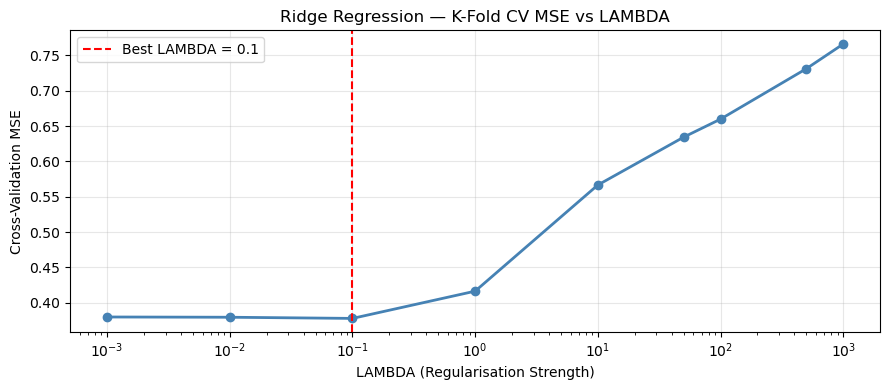

In [34]:
plt.figure(figsize=(9, 4))
plt.plot(LAMBDAS, cv_scores, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_lambda, color='red', linestyle='--', 
            label=f'Best LAMBDA = {best_lambda}')
plt.xscale('log')
plt.xlabel('LAMBDA (Regularisation Strength)')
plt.ylabel('Cross-Validation MSE')
plt.title('Ridge Regression — K-Fold CV MSE vs LAMBDA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [35]:
# Training final optimal model after regularisation and validation, with best lambda

ridge_best_lr = Ridge(alpha=best_lambda)
ridge_best_lr.fit(X_train, y_train)

,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [36]:
# Predict

y_pred_train_ridge_lr = ridge_best_lr.predict(X_train)
y_pred_test_ridge_lr  = ridge_best_lr.predict(X_test)



In [37]:

mse_train_ridge_lr = mean_squared_error(y_train, y_pred_train_ridge_lr)
mse_test_ridge_lr  = mean_squared_error(y_test,  y_pred_test_ridge_lr)


print(f"Best lambda : {best_lambda}")
print(f"Train MSE  : {mse_train_ridge_lr:.4f}")
print(f"Test  MSE  : {mse_test_ridge_lr:.4f}")

Best lambda : 0.1
Train MSE  : 0.2994
Test  MSE  : 0.2763


#### Implementing Random Forest Regressor

In [39]:
# Building and fitting RF model

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
# Predict

y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf  = rf.predict(X_test)

In [41]:
mse_train_rf = mean_squared_error(y_train, y_pred_train_rf)
mse_test_rf  = mean_squared_error(y_test,  y_pred_test_rf)

print(f"Train MSE : {mse_train_rf:.4f}")
print(f"Test  MSE : {mse_test_rf:.4f}")

Train MSE : 0.0493
Test  MSE : 0.2251


In [42]:
rf.score(X_train, y_train)

0.950734496162363

In [43]:
rf.score(X_test, y_test)

0.7303627545999957

#### Finding best hyperparameters with validation to improve model performance

In [48]:
# K-FOLD CV to find best hyperparameters

hparam_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth'    : [5, 10, 20, None]   # None = fully grown
}

kf_rf = KFold(n_splits=5, shuffle=True, random_state=42)

In [49]:
rf_cv = GridSearchCV(
    estimator  = RandomForestRegressor(random_state=42),
    param_grid = hparam_grid,
    cv         = kf_rf,
    scoring    = 'neg_mean_squared_error',
    n_jobs     = -1,      
    verbose    = 1
)

rf_cv.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [50]:
print(f"Best parameters : {rf_cv.best_params_}")
print(f"Best CV MSE     : {-rf_cv.best_score_:.4f}")

Best parameters : {'max_depth': None, 'n_estimators': 200}
Best CV MSE     : 0.3969


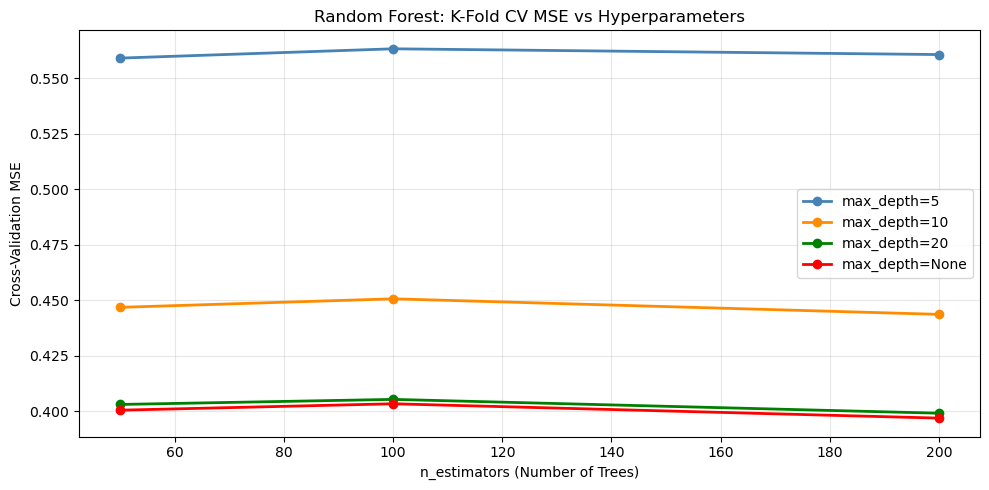

In [60]:
results = rf_cv.cv_results_
params  = results['params']
scores  = -results['mean_test_score']

plt.subplots(figsize=(10, 5))
depths = [5, 10, 20, None]
colors = ['steelblue', 'darkorange', 'green', 'red']

for depth, color in zip(depths, colors):
    mask = [p['max_depth'] == depth for p in params]
    n_ests = [p['n_estimators'] for p, m in zip(params, mask) if m]
    mses   = [s for s, m in zip(scores, mask) if m]
    plt.plot(n_ests, mses, marker='o', label=f'max_depth={depth}', 
            color=color, linewidth=2)

plt.xlabel('n_estimators (Number of Trees)')
plt.ylabel('Cross-Validation MSE')
plt.title('Random Forest: K-Fold CV MSE vs Hyperparameters')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
# FINAL RF with best hyperparameters
    
best_rf = rf_cv.best_estimator_
best_rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
y_pred_train_best = best_rf.predict(X_train)
y_pred_test_best  = best_rf.predict(X_test)

In [63]:
mse_train_best_rf = mean_squared_error(y_train, y_pred_train_best)
mse_test_best_rf  = mean_squared_error(y_test,  y_pred_test_best)

print(f"Best Params : {rf_cv.best_params_}")
print(f"Train MSE   : {mse_train_best_rf:.4f}")
print(f"Test  MSE   : {mse_test_best_rf:.4f}")

Best Params : {'max_depth': None, 'n_estimators': 200}
Train MSE   : 0.0490
Test  MSE   : 0.2250


In [64]:
best_rf.score(X_train, y_train)

0.9509921517433637

In [65]:
best_rf.score(X_test, y_test)

0.7305307403629422

### Task 3: Implementing Classification

In [ ]:
# X_train_clf, X_test_clf, y_train_clf, y_test_clf

In [121]:
lgr_plain = LogisticRegression(
    penalty    = None,       
    solver     = 'saga',      
    max_iter   = 5000,        
    random_state = 42
)

lgr_plain.fit(X_train_clf, y_train_clf)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'saga'
,max_iter,5000
,multi_class,'deprecated'


In [122]:
lgr_plain.score(X_train_clf, y_train_clf)

0.8310258023914412

In [123]:
lgr_plain.score(X_test_clf, y_test_clf)

0.827826725403818

In [125]:
# Making Predictions

y_pred_train_plain = lgr_plain.predict(X_train_clf)
y_pred_test_plain  = lgr_plain.predict(X_test_clf)

In [127]:
print("PLAIN Logistic Regression without any no regularisation")

label_names = ['low', 'medium', 'high']

print(f"Train Accuracy : {accuracy_score(y_train_clf, y_pred_train_plain):.4f}")
print(f"Test  Accuracy : {accuracy_score(y_test_clf,  y_pred_test_plain):.4f}")

print("Test Classification Report")
print(classification_report(y_test_clf, y_pred_test_plain, target_names=label_names))


PLAIN Logistic Regression without any no regularisation
Train Accuracy : 0.8310
Test  Accuracy : 0.8278
Test Classification Report
              precision    recall  f1-score   support

         low       0.81      0.60      0.69       680
      medium       0.84      0.94      0.89      1919
        high       0.67      0.30      0.41       125

    accuracy                           0.83      2724
   macro avg       0.77      0.61      0.66      2724
weighted avg       0.82      0.83      0.82      2724



In [130]:
 # K-Fold CV to find best C with L1 regularisation

kf = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

lgr_tuned = GridSearchCV(
    estimator = LogisticRegression(
        penalty      = 'l1',       
        solver       = 'saga',     
        max_iter     = 5000,
        random_state = 42
    ),
    param_grid = param_grid,
    cv         = kf,
    scoring    = 'accuracy',
    n_jobs     = -1
)

lgr_tuned.fit(X_train_clf, y_train_clf)

,estimator,LogisticRegre...solver='saga')
,param_grid,"{'C': [0.001, 0.01, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [134]:
cv_results = lgr_tuned.cv_results_

for mean, param in zip(cv_results['mean_test_score'], cv_results['params']):
    print(f"  C={param['C']:8.3f}: CV Accuracy={mean:.4f}")

print(f"Best C        : {lgr_tuned.best_params_['C']}")
print(f"Best CV Score : {lgr_tuned.best_score_:.4f}")

  C=   0.001: CV Accuracy=0.7067
  C=   0.010: CV Accuracy=0.7981
  C=   0.100: CV Accuracy=0.8147
  C=   1.000: CV Accuracy=0.8280
  C=  10.000: CV Accuracy=0.8277
  C= 100.000: CV Accuracy=0.8274
Best C        : 1
Best CV Score : 0.8280


In [141]:

best_lgr = lgr_tuned.best_estimator_


In [142]:
y_pred_train_tuned = best_lgr.predict(X_train_clf)
y_pred_test_tuned  = best_lgr.predict(X_test_clf)

In [143]:
print("TUNED Logistic Regression: L1, best C")

print(f"Train Accuracy : {accuracy_score(y_train_clf, y_pred_train_tuned):.4f}")
print(f"Test  Accuracy : {accuracy_score(y_test_clf,  y_pred_test_tuned):.4f}")

print("\n── Test Classification Report ──────────────────────────")
print(classification_report(y_test_clf, y_pred_test_tuned,
                             target_names=label_names))

TUNED Logistic Regression: L1, best C
Train Accuracy : 0.8317
Test  Accuracy : 0.8245

── Test Classification Report ──────────────────────────
              precision    recall  f1-score   support

         low       0.81      0.59      0.69       680
      medium       0.83      0.95      0.88      1919
        high       0.79      0.18      0.29       125

    accuracy                           0.82      2724
   macro avg       0.81      0.57      0.62      2724
weighted avg       0.82      0.82      0.81      2724



In [144]:
avg = 'weighted'

comparison = pd.DataFrame({
    'Model'    : ['LR Plain (no reg)', 'LR Tuned (L1)'],
    'Train Acc': [
        accuracy_score(y_train_clf, y_pred_train_plain),
        accuracy_score(y_train_clf, y_pred_train_tuned)
    ],
    'Test Acc' : [
        accuracy_score(y_test_clf, y_pred_test_plain),
        accuracy_score(y_test_clf, y_pred_test_tuned)
    ],
    'Precision': [
        precision_score(y_test_clf, y_pred_test_plain, average=avg),
        precision_score(y_test_clf, y_pred_test_tuned, average=avg)
    ],
    'Recall'   : [
        recall_score(y_test_clf, y_pred_test_plain, average=avg),
        recall_score(y_test_clf, y_pred_test_tuned, average=avg)
    ],
    'F1 Score' : [
        f1_score(y_test_clf, y_pred_test_plain, average=avg),
        f1_score(y_test_clf, y_pred_test_tuned, average=avg)
    ]
}).set_index('Model').round(4)

print(comparison)

                   Train Acc  Test Acc  Precision  Recall  F1 Score
Model                                                              
LR Plain (no reg)     0.8310    0.8278     0.8223  0.8278    0.8156
LR Tuned (L1)         0.8317    0.8245     0.8221  0.8245    0.8072


In [156]:
train_confusion_matrix = confusion_matrix(y_true=y_train_clf, y_pred=y_pred_train_plain)

print(train_confusion_matrix)

[[ 982  606    0]
 [ 212 4222   44]
 [   0  212   78]]


In [148]:
test_confusion_matrix = confusion_matrix(y_true=y_test_clf, y_pred=y_pred_test_tuned)

print(test_confusion_matrix)

[[ 403  277    0]
 [  92 1821    6]
 [   0  103   22]]


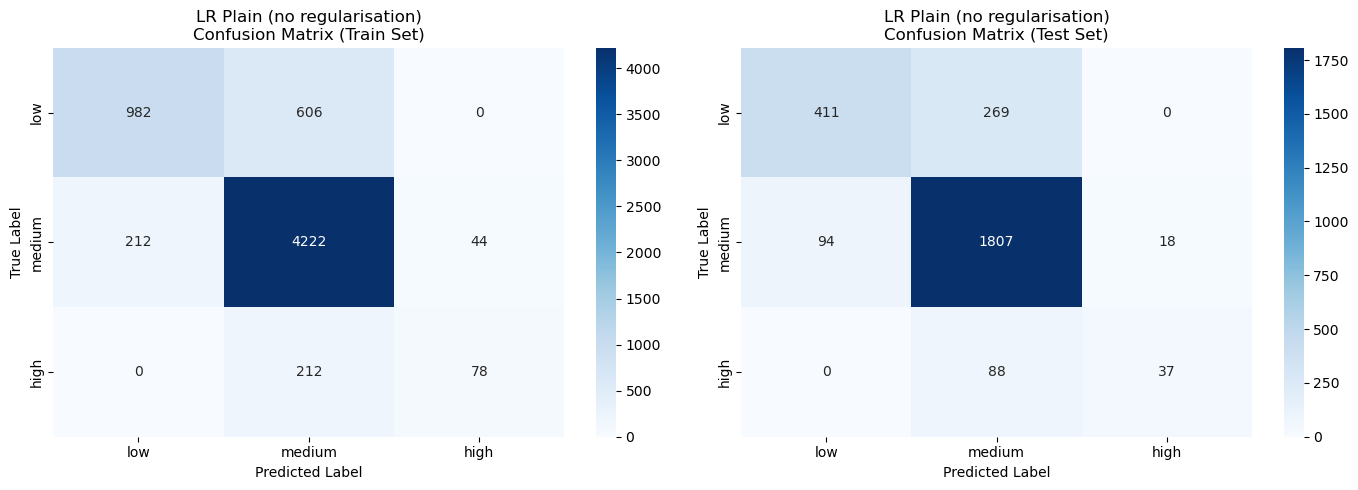

In [155]:
label_names = ['low', 'medium', 'high']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train_clf, y_test_clf],
    [y_pred_train_plain, y_pred_test_plain],
    ['LR Plain (no regularisation)\nConfusion Matrix (Train Set)',
     'LR Plain (no regularisation)\nConfusion Matrix (Test Set)']
):
    cm = confusion_matrix(y_true, y_pred)
    
    sns.heatmap(cm, 
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names,
                ax=ax)
    
    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()

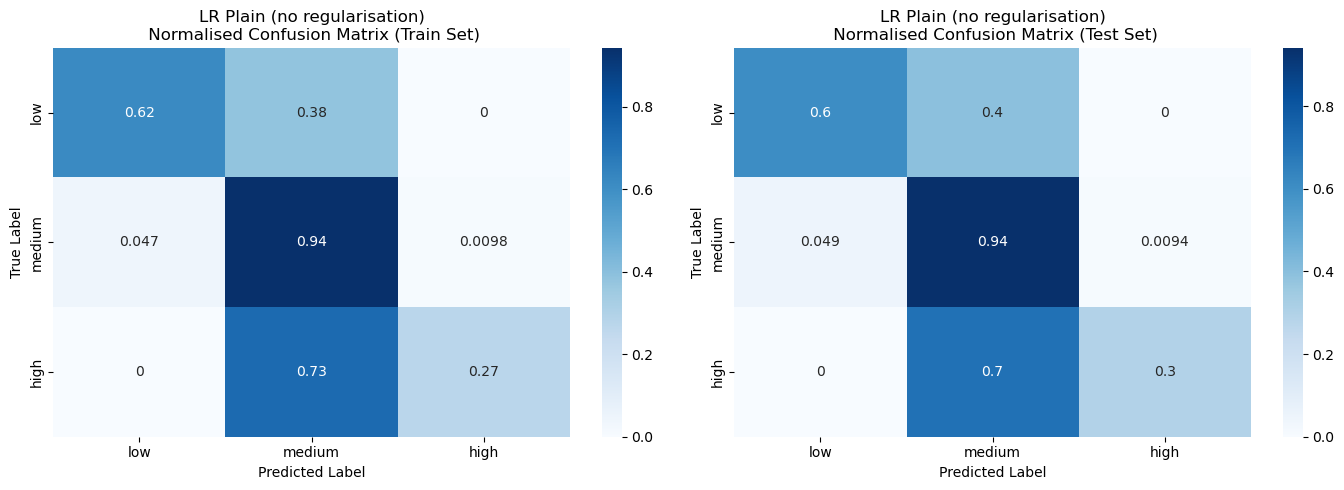

In [159]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train_clf, y_test_clf],
    [y_pred_train_plain, y_pred_test_plain],
    ['LR Plain (no regularisation)\n Normalised Confusion Matrix (Train Set)',
     'LR Plain (no regularisation)\n Normalised Confusion Matrix (Test Set)']
):
    cm = confusion_matrix(y_true, y_pred)
    ncm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(ncm, 
                annot=True,
                # fmt='d',
                cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names,
                ax=ax)
    
    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()

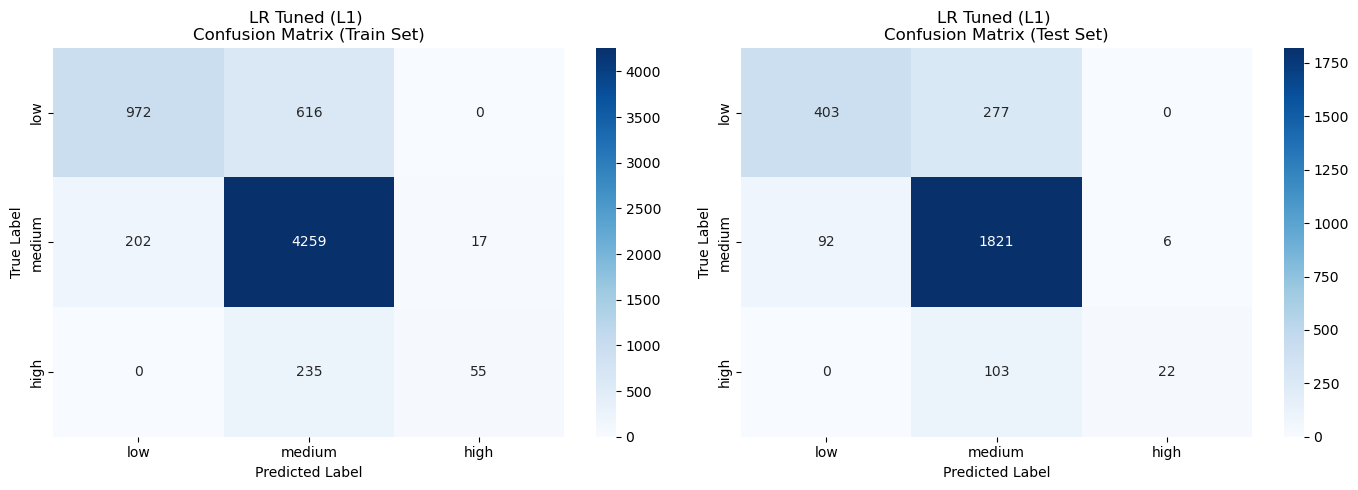

In [160]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train_clf, y_test_clf],
    [y_pred_train_tuned, y_pred_test_tuned],
    ['LR Tuned (L1) \nConfusion Matrix (Train Set)',
     'LR Tuned (L1) \nConfusion Matrix (Test Set)']
):
    cm = confusion_matrix(y_true, y_pred)
    
    sns.heatmap(cm, 
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names,
                ax=ax)
    
    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()

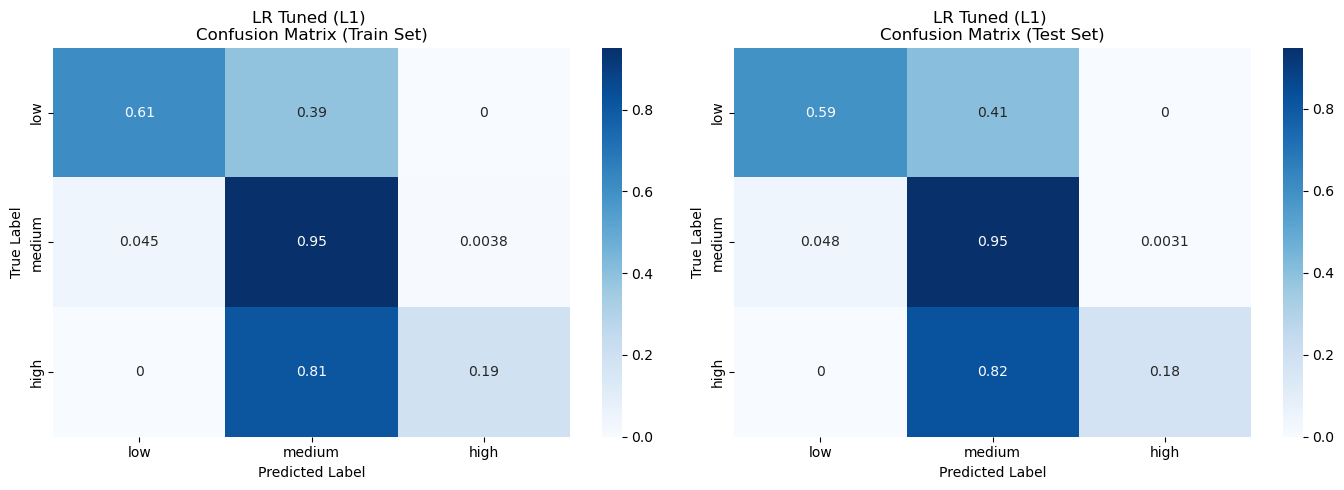

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


for ax, y_true, y_pred, title in zip(
    axes,
    [y_train_clf, y_test_clf],
    [y_pred_train_tuned, y_pred_test_tuned],
    ['LR Tuned (L1) \nConfusion Matrix (Train Set)',
     'LR Tuned (L1) \nConfusion Matrix (Test Set)']
):
    cm = confusion_matrix(y_true, y_pred)
    ncm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(ncm, 
                annot=True,
                # fmt='d',
                cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names,
                ax=ax)
    
    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()

In [167]:
# Plain Random Forest with default parameters, and tuning

rf_plain_clf = RandomForestClassifier(
    n_estimators = 100,     
    random_state = 42
)

rf_plain_clf.fit(X_train_clf, y_train_clf)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [168]:
y_pred_train_rf_plain_clf = rf_plain_clf.predict(X_train_clf)
y_pred_test_rf_plain_clf  = rf_plain_clf.predict(X_test_clf)

In [172]:
print("PLAIN Random Forest")
print(f"Train Accuracy : {accuracy_score(y_train_clf, y_pred_train_rf_plain_clf):.4f}")
print(f"Test  Accuracy : {accuracy_score(y_test_clf,  y_pred_test_rf_plain_clf):.4f}")

print("Test Classification Report ──────────────────────────")
print(classification_report(y_test_clf, y_pred_test_rf_plain_clf, target_names=label_names))

PLAIN Random Forest
Train Accuracy : 0.9989
Test  Accuracy : 0.8047
Test Classification Report ──────────────────────────
              precision    recall  f1-score   support

         low       0.70      0.70      0.70       680
      medium       0.86      0.87      0.86      1919
        high       0.48      0.42      0.45       125

    accuracy                           0.80      2724
   macro avg       0.68      0.66      0.67      2724
weighted avg       0.80      0.80      0.80      2724



In [173]:
# K-Fold CV to tune hyperparameters

kf = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid_rf = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [5, 10, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

rf_tuned_clf = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid_rf,
    cv         = kf,
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 1
)

rf_tuned_clf.fit(X_train_clf, y_train_clf)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [175]:
print(f"Best Params   : {rf_tuned_clf.best_params_}")
print(f"Best CV Score : {rf_tuned_clf.best_score_:.4f}")

Best Params   : {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV Score : 0.8295


In [176]:
best_rf_clf = rf_tuned_clf.best_estimator_

y_pred_train_rf_tuned_clf = best_rf_clf.predict(X_train_clf)
y_pred_test_rf_tuned_clf  = best_rf_clf.predict(X_test_clf)

In [177]:
print("TUNED Random Forest")
print(f"Train Accuracy : {accuracy_score(y_train_clf, y_pred_train_rf_tuned_clf):.4f}")
print(f"Test  Accuracy : {accuracy_score(y_test_clf,  y_pred_test_rf_tuned_clf):.4f}")

print("Test Classification Report ")
print(classification_report(y_test_clf, y_pred_test_rf_tuned_clf,
                             target_names=label_names))

TUNED Random Forest
Train Accuracy : 0.9185
Test  Accuracy : 0.8216
Test Classification Report 
              precision    recall  f1-score   support

         low       0.82      0.60      0.69       680
      medium       0.84      0.93      0.88      1919
        high       0.50      0.33      0.40       125

    accuracy                           0.82      2724
   macro avg       0.72      0.62      0.66      2724
weighted avg       0.82      0.82      0.81      2724



In [178]:
avg = 'weighted'

comparison_rf_clf = pd.DataFrame({
    'Model'    : ['RF Plain Classifier', 'RF Tuned Classifier'],
    'Train Acc': [
        accuracy_score(y_train_clf, y_pred_train_rf_plain_clf),
        accuracy_score(y_train_clf, y_pred_train_rf_tuned_clf)
    ],
    'Test Acc' : [
        accuracy_score(y_test_clf, y_pred_test_rf_plain_clf),
        accuracy_score(y_test_clf, y_pred_test_rf_tuned_clf)
    ],
    'Precision': [
        precision_score(y_test_clf, y_pred_test_rf_plain_clf, average=avg),
        precision_score(y_test_clf, y_pred_test_rf_tuned_clf, average=avg)
    ],
    'Recall'   : [
        recall_score(y_test_clf, y_pred_test_rf_plain_clf, average=avg),
        recall_score(y_test_clf, y_pred_test_rf_tuned_clf, average=avg)
    ],
    'F1 Score' : [
        f1_score(y_test_clf, y_pred_test_rf_plain_clf, average=avg),
        f1_score(y_test_clf, y_pred_test_rf_tuned_clf, average=avg)
    ]
}).set_index('Model').round(4)

print(comparison_rf_clf)

                     Train Acc  Test Acc  Precision  Recall  F1 Score
Model                                                                
RF Plain Classifier     0.9989    0.8047     0.8022  0.8047    0.8033
RF Tuned Classifier     0.9185    0.8216     0.8151  0.8216    0.8117


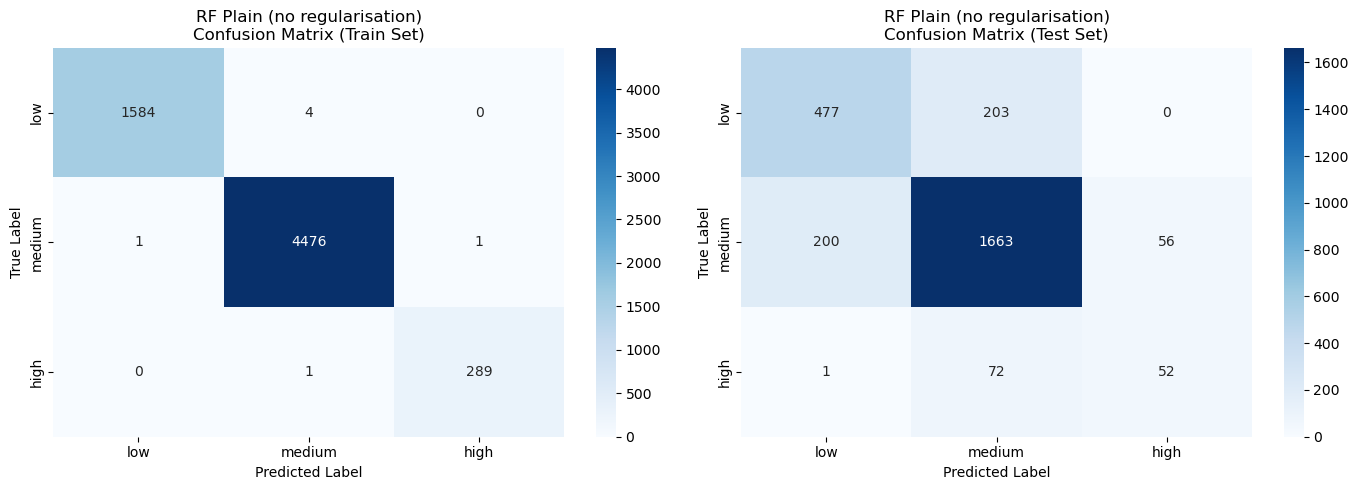

In [179]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train_clf, y_test_clf],
    [y_pred_train_rf_plain_clf, y_pred_test_rf_plain_clf],
    ['RF Plain (no regularisation)\nConfusion Matrix (Train Set)',
     'RF Plain (no regularisation)\nConfusion Matrix (Test Set)']
):
    cm = confusion_matrix(y_true, y_pred)
    
    sns.heatmap(cm, 
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names,
                ax=ax)
    
    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()

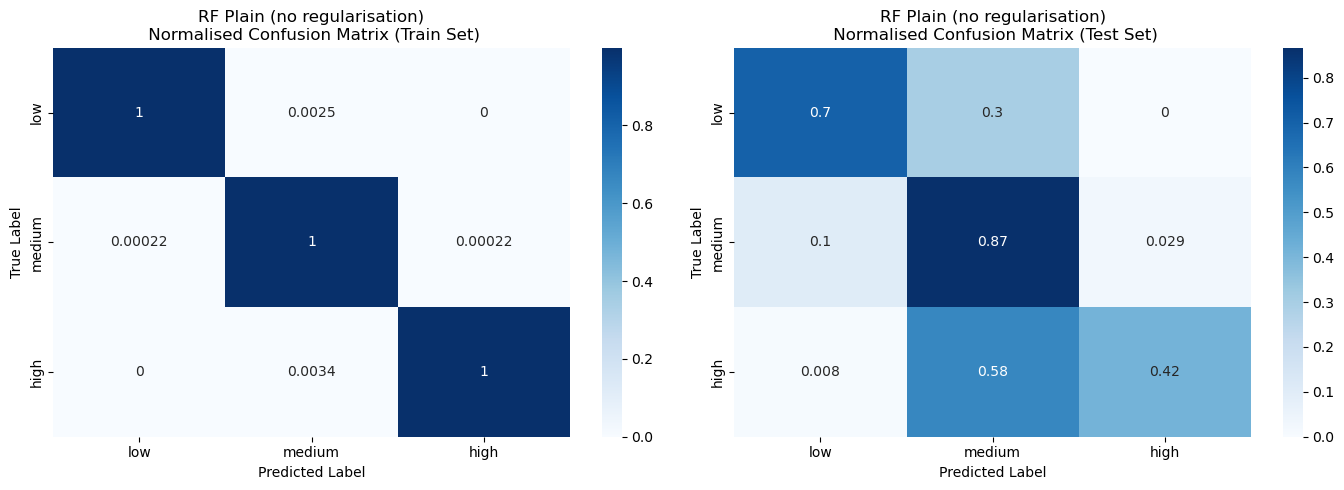

In [180]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train_clf, y_test_clf],
    [y_pred_train_rf_plain_clf, y_pred_test_rf_plain_clf],
    ['RF Plain (no regularisation)\n Normalised Confusion Matrix (Train Set)',
     'RF Plain (no regularisation)\n Normalised Confusion Matrix (Test Set)']
):
    cm = confusion_matrix(y_true, y_pred)
    ncm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(ncm, 
                annot=True,
                # fmt='d',
                cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names,
                ax=ax)
    
    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()

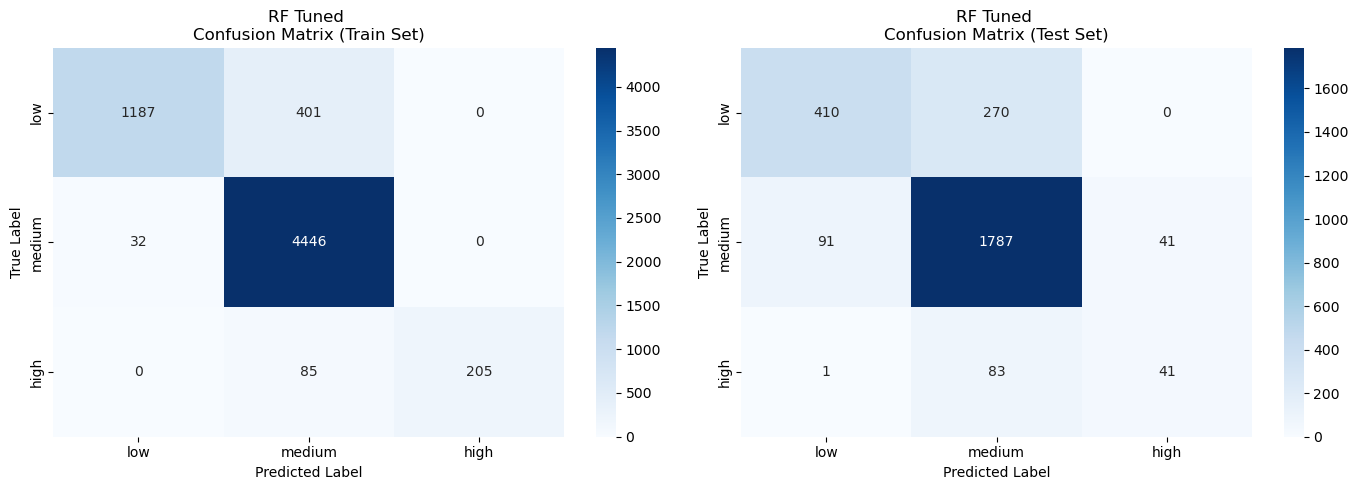

In [181]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train_clf, y_test_clf],
    [y_pred_train_rf_tuned_clf, y_pred_test_rf_tuned_clf],
    ['RF Tuned \nConfusion Matrix (Train Set)',
     'RF Tuned \nConfusion Matrix (Test Set)']
):
    cm = confusion_matrix(y_true, y_pred)
    
    sns.heatmap(cm, 
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names,
                ax=ax)
    
    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()

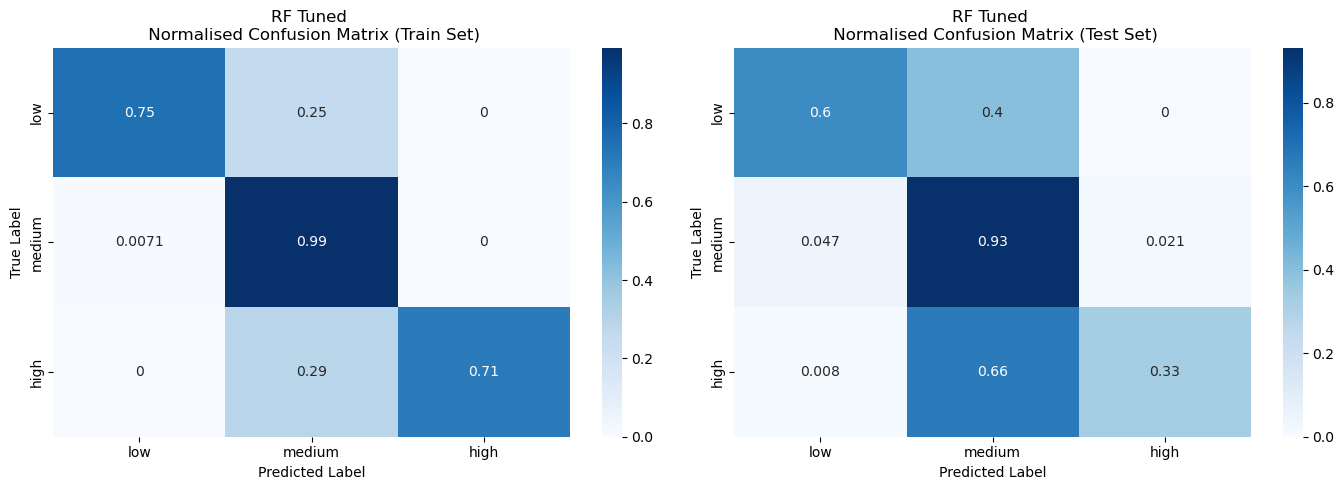

In [182]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train_clf, y_test_clf],
    [y_pred_train_rf_tuned_clf, y_pred_test_rf_tuned_clf],
    ['RF Tuned \n Normalised Confusion Matrix (Train Set)',
     'RF Tuned \n Normalised Confusion Matrix (Test Set)']
):
    cm = confusion_matrix(y_true, y_pred)
    ncm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(ncm, 
                annot=True,
                # fmt='d',
                cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names,
                ax=ax)
    
    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()

### Task 4: Feature Selection

In [9]:
df_fi = pd.read_csv('LondonCars2014.csv')

le = LabelEncoder()
cat_cols = ['Make', 'Model', 'Body Style', 
            'Ex Color', 'In Color', 'Engine', 'Transmission']

for col in cat_cols:
    df_fi[col] = le.fit_transform(df_fi[col].astype(str))

print(df_fi.head())

   Make  Model  Year  Mileage  Price  Body Style  Ex Color  In Color  Engine  \
0    46    134  2014     4725  28995           7         6         0       5   
1    12    353  2014    17201  24994           6        12         0       3   
2    16    840  2014     6279  25998           6        12         3       3   
3    12    353  2014    16262  26684           6         1         0       3   
4    19    485  2014    35572  33440           6         1         0       5   

   Transmission  Doors  
0             0      4  
1             0      4  
2             0      4  
3             0      4  
4             0      4  


In [11]:
X_fi = df_fi.drop(columns=['Price'])
y_fi = df_fi['Price']

print("Features:", X_fi.columns.tolist())

Features: ['Make', 'Model', 'Year', 'Mileage', 'Body Style', 'Ex Color', 'In Color', 'Engine', 'Transmission', 'Doors']


In [12]:
X_train_fi, X_test_fi, y_train_fi, y_test_fi = train_test_split(
    X_fi, y_fi,
    test_size    = 0.30,
    random_state = 42
)

In [13]:
numeric_cols = ['Year', 'Mileage', 'Doors']
scaler = StandardScaler()
X_train_fi[numeric_cols] = scaler.fit_transform(X_train_fi[numeric_cols])
X_test_fi[numeric_cols]  = scaler.transform(X_test_fi[numeric_cols])

In [212]:
# Scaling target

scaler_y_fi = StandardScaler()
y_train_fi_scaled = scaler_y_fi.fit_transform(y_train_fi.values.reshape(-1,1)).flatten()
y_test_fi_scaled  = scaler_y_fi.transform(y_test_fi.values.reshape(-1,1)).flatten()

In [213]:
# Train RF on ALL features

rf_fi = RandomForestRegressor(n_estimators=200, random_state=42)
rf_fi.fit(X_train_fi, y_train_fi_scaled)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [214]:
mse_train_all = mean_squared_error(y_train_fi_scaled, rf_fi.predict(X_train_fi))
mse_test_all  = mean_squared_error(y_test_fi_scaled,  rf_fi.predict(X_test_fi))

print("RF with ALL features")
print(f"Train MSE : {mse_train_all:.4f}")
print(f"Test  MSE : {mse_test_all:.4f}")

RF with ALL features
Train MSE : 0.0190
Test  MSE : 0.2242


In [215]:
# Extracting feature importances

importance_df = pd.DataFrame({
    'Feature'   : X_train_fi.columns,
    'Importance': rf_fi.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Feature Importances:")
print(importance_df)


Feature Importances:
        Feature  Importance
0        Engine    0.376957
1       Mileage    0.204990
2         Model    0.137634
3          Make    0.136446
4          Year    0.078987
5    Body Style    0.030065
6      In Color    0.016472
7      Ex Color    0.011918
8         Doors    0.003932
9  Transmission    0.002597


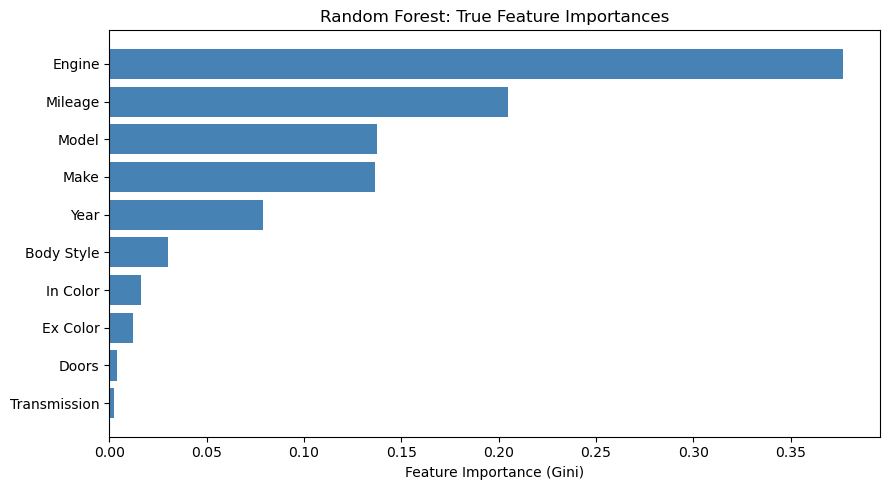

In [217]:
plt.figure(figsize=(9, 5))
plt.barh(importance_df['Feature'][::-1],
         importance_df['Importance'][::-1],
         color='steelblue')
plt.xlabel('Feature Importance (Gini)')
plt.title('Random Forest: True Feature Importances')
plt.tight_layout()
plt.show()

Features needed for 90% importance : 5
Features needed for 95% importance : 6


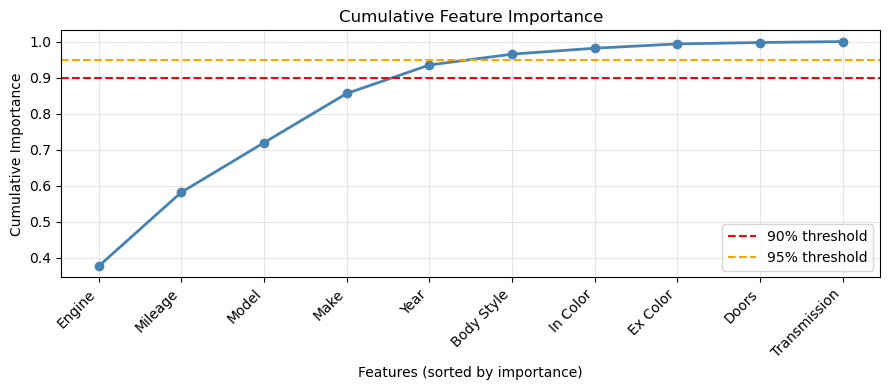

In [226]:
cumulative = importance_df['Importance'].cumsum()

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cumulative)+1), cumulative,
         marker='o', color='steelblue', linewidth=2)
plt.axhline(y=0.90, color='red',    linestyle='--', label='90% threshold')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% threshold')
plt.xticks(range(1, len(cumulative)+1), importance_df['Feature'], rotation=45, ha='right')
plt.xlabel('Features (sorted by importance)')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

n_90 = (cumulative < 0.90).sum() + 1
n_95 = (cumulative < 0.95).sum() + 1
print(f"Features needed for 90% importance : {n_90}")
print(f"Features needed for 95% importance : {n_95}")

In [227]:
top_features = importance_df['Feature'][:n_90].tolist()
print(f"\nSelected features: {top_features}")


Selected features: ['Engine', 'Mileage', 'Model', 'Make', 'Year']


In [228]:
X_train_sel = X_train_fi[top_features]
X_test_sel  = X_test_fi[top_features]

In [230]:
X_train_sel.head()

,Engine,Mileage,Model,Make,Year
7531,5,-0.600535,501,46,0.544564
5594,5,1.640748,44,3,-0.182665
1979,6,1.341200,854,46,-2.000739
1883,8,1.274553,768,23,-1.273510
438,5,-0.314792,767,23,0.180949


In [231]:
rf_selected = RandomForestRegressor(n_estimators=200, random_state=42)
rf_selected.fit(X_train_sel, y_train_fi_scaled)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [232]:
mse_train_sel = mean_squared_error(y_train_fi_scaled, rf_selected.predict(X_train_sel))
mse_test_sel  = mean_squared_error(y_test_fi_scaled, rf_selected.predict(X_test_sel))

print(f"RF with Top {n_90} Selected Features")
print(f"Train MSE : {mse_train_sel:.4f}")
print(f"Test  MSE : {mse_test_sel:.4f}")

RF with Top 5 Selected Features
Train MSE : 0.0184
Test  MSE : 0.2179


In [239]:
comparison = pd.DataFrame({
    'Model'    : [
        'RF (3 features: Task 2)',
        f'RF ({n_90} selected features)',
        f'RF (all {X_train_fi.shape[1]} features)'
    ],
    'Train MSE': [mse_train_rf, mse_train_sel, mse_train_all],
    'Test MSE' : [mse_test_rf,  mse_test_sel,  mse_test_all]
}).set_index('Model').round(4)

print(comparison)

                          Train MSE  Test MSE
Model                                        
RF (3 features: Task 2)      0.0493    0.2251
RF (5 selected features)     0.0184    0.2179
RF (all 10 features)         0.0190    0.2242
